# <center>**District Wise IPC Crimes 2022**</center>

About

This project analyzes Indian Penal Code (IPC) crimes recorded across various districts in India during the year 2022. The raw dataset, titled "District-wise IPC Crimes from 2017 Onwards," was obtained from the official Indian Data Portal.

Rather than evaluating all offenses indiscriminately, this study specifically filters and focuses on a selected set of major crimes—such as murder, acid attacks, and assault on women committed exclusively in 2022. By evaluating these key specific crimes, we can gain a clear, targeted understanding of the critical law and order landscape across different regions of the country.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv(r"C:\Users\govin\OneDrive\Desktop\Data Analysis\Final Project\districtwise-ipc-crimes-2022.csv")
df

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,acid_attack,assault_on_women,criminal_trespass,crlty_husbnd_relatives,criminal_intimidation,insult_modesty_women,other_ipc_crimes
0,1,2022,Andhra Pradesh,28,Chittoor,503,Chittoor,30,0,146,156,357,52,74,569
1,2,2022,Andhra Pradesh,28,East Godavari,505,East Godavari,25,0,35,142,672,60,151,399
2,3,2022,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,1,0,0,2,1,0,2,10
3,4,2022,Andhra Pradesh,28,Guntur,506,Guntur,37,0,163,121,1054,511,510,174
4,5,2022,Andhra Pradesh,28,Krishna,510,Krishna,29,0,134,45,766,239,239,534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,929,2022,Jammu And Kashmir,1,Srinagar,13,Special Crime Wing Kashmir,0,0,0,0,0,0,0,0
929,930,2022,Jammu And Kashmir,1,Srinagar,13,Anti Narcotic Task Force Kashmir,0,0,0,0,0,0,0,0
930,931,2022,Jammu And Kashmir,1,Jammu,5,Economic Offences Wing (Eow) Jammu,0,0,0,0,0,0,0,0
931,932,2022,Jammu And Kashmir,1,Srinagar,13,Economic Offences Wing (Eow) Kashmir,0,0,0,0,0,0,0,0


In [3]:
df.head()

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,acid_attack,assault_on_women,criminal_trespass,crlty_husbnd_relatives,criminal_intimidation,insult_modesty_women,other_ipc_crimes
0,1,2022,Andhra Pradesh,28,Chittoor,503,Chittoor,30,0,146,156,357,52,74,569
1,2,2022,Andhra Pradesh,28,East Godavari,505,East Godavari,25,0,35,142,672,60,151,399
2,3,2022,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,1,0,0,2,1,0,2,10
3,4,2022,Andhra Pradesh,28,Guntur,506,Guntur,37,0,163,121,1054,511,510,174
4,5,2022,Andhra Pradesh,28,Krishna,510,Krishna,29,0,134,45,766,239,239,534


In [4]:
df.shape

(933, 15)

In [5]:
df.columns

Index(['id', 'year', 'state_name', 'state_code', 'district_name',
       'district_code', 'registration_circles', 'murder', 'acid_attack',
       'assault_on_women', 'criminal_trespass', 'crlty_husbnd_relatives',
       'criminal_intimidation', 'insult_modesty_women', 'other_ipc_crimes'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      933 non-null    int64 
 1   year                    933 non-null    int64 
 2   state_name              933 non-null    object
 3   state_code              933 non-null    int64 
 4   district_name           933 non-null    object
 5   district_code           933 non-null    int64 
 6   registration_circles    933 non-null    object
 7   murder                  933 non-null    int64 
 8   acid_attack             933 non-null    int64 
 9   assault_on_women        933 non-null    int64 
 10  criminal_trespass       933 non-null    int64 
 11  crlty_husbnd_relatives  933 non-null    int64 
 12  criminal_intimidation   933 non-null    int64 
 13  insult_modesty_women    933 non-null    int64 
 14  other_ipc_crimes        933 non-null    int64 
dtypes: int

## 1. Dataset Features

* **id** – Unique identifier for each record
* **year** – The year the data was recorded (e.g., 2022)
* **state_name** – Name of the state (e.g., Andhra Pradesh)
* **state_code** – Numerical code assigned to the state
* **district_name** – Name of the district (e.g., Krishna)
* **district_code** – Numerical code assigned to the district
* **registration_circles** – Number of registration circles or administrative boundaries
* **murder** – Number of recorded murder cases
* **acid_attack** – Number of recorded acid attack cases
* **assault_on_women** – Number of recorded assault on women cases
* **criminal_trespass** – Number of recorded criminal trespass cases
* **crlty_husbnd_relatives** – Number of cases regarding cruelty by husband or his relatives
* **criminal_intimidation** – Number of recorded criminal intimidation cases
* **insult_modesty_women** – Number of recorded cases of insult to the modesty of women
* **other_ipc_crimes** – Number of other Indian Penal Code (IPC) crimes recorded


### 2. Dataset Dimensions
* **Total Rows:** 933 entries
* **Total Columns:** 15 features

## 3. Handling Missing Values in the data

In [7]:
print(df.isnull().sum())

id                        0
year                      0
state_name                0
state_code                0
district_name             0
district_code             0
registration_circles      0
murder                    0
acid_attack               0
assault_on_women          0
criminal_trespass         0
crlty_husbnd_relatives    0
criminal_intimidation     0
insult_modesty_women      0
other_ipc_crimes          0
dtype: int64


From the above observation we can conclude that there is no null or blank values in the data

## 4.Duplicate Values

In [8]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


From the above observation we can see that there is no such duplicates values in the data

## 5.Updating the column names

The original column names contain abbreviations and underscores, making them less readable. To standardize the dataset for professional reporting, we will:
* Rename heavily abbreviated columns into descriptive, easily understandable titles.
* Remove underscores and apply title-case capitalization to all headers for consistent formatting.

In [9]:
df = df.rename(columns={"crlty_husbnd_relatives": "Cruelty By Husband Or Relatives",
    "insult_modesty_women": 'Insult To Modesty Of Women'})

In [10]:
df.columns = df.columns.str.replace("_", " ").str.title()

In [11]:
print("Updated Column Names:")
print(df.columns.tolist())

Updated Column Names:
['Id', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles', 'Murder', 'Acid Attack', 'Assault On Women', 'Criminal Trespass', 'Cruelty By Husband Or Relatives', 'Criminal Intimidation', 'Insult To Modesty Of Women', 'Other Ipc Crimes']


## 6.Total crimes happened in each district

Since the raw dataset only tracks granular, individual crime categories, we will compute a new derived feature, Total IPC Crimes, by aggregating all numeric offense columns row-by-row for each district.

In [12]:
crime_columns = ["Murder", "Acid Attack", "Assault On Women", "Criminal Trespass","Cruelty By Husband Or Relatives", "Criminal Intimidation", 
                 "Insult To Modesty Of Women", "Other Ipc Crimes"]

df["Total IPC Crimes"] = df[crime_columns].sum(axis=1)

df[["State Name", "District Name", "Total IPC Crimes"]].head(3)

,State Name,District Name,Total IPC Crimes
0,Andhra Pradesh,Chittoor,1384
1,Andhra Pradesh,East Godavari,1484
2,Andhra Pradesh,Ananthapuramu,16


# 7.Total crimes happened in each state

To capture a high-level geographical perspective, we will aggregate the district-level data to calculate the total cumulative IPC crimes recorded for each individual state and Union Territory.

State_Crimes = df.groupby("State Name")["Total IPC Crimes"].sum().reset_index()
State_Crimes

In [13]:
print(df.columns.tolist())

['Id', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles', 'Murder', 'Acid Attack', 'Assault On Women', 'Criminal Trespass', 'Cruelty By Husband Or Relatives', 'Criminal Intimidation', 'Insult To Modesty Of Women', 'Other Ipc Crimes', 'Total IPC Crimes']


# Exploratory Data Analysis (EDA) and Visualization

In [14]:
df

,Id,Year,State Name,State Code,District Name,District Code,Registration Circles,Murder,Acid Attack,Assault On Women,Criminal Trespass,Cruelty By Husband Or Relatives,Criminal Intimidation,Insult To Modesty Of Women,Other Ipc Crimes,Total IPC Crimes
0,1,2022,Andhra Pradesh,28,Chittoor,503,Chittoor,30,0,146,156,357,52,74,569,1384
1,2,2022,Andhra Pradesh,28,East Godavari,505,East Godavari,25,0,35,142,672,60,151,399,1484
2,3,2022,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,1,0,0,2,1,0,2,10,16
3,4,2022,Andhra Pradesh,28,Guntur,506,Guntur,37,0,163,121,1054,511,510,174,2570
4,5,2022,Andhra Pradesh,28,Krishna,510,Krishna,29,0,134,45,766,239,239,534,1986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,929,2022,Jammu And Kashmir,1,Srinagar,13,Special Crime Wing Kashmir,0,0,0,0,0,0,0,0,0
929,930,2022,Jammu And Kashmir,1,Srinagar,13,Anti Narcotic Task Force Kashmir,0,0,0,0,0,0,0,0,0
930,931,2022,Jammu And Kashmir,1,Jammu,5,Economic Offences Wing (Eow) Jammu,0,0,0,0,0,0,0,0,0
931,932,2022,Jammu And Kashmir,1,Srinagar,13,Economic Offences Wing (Eow) Kashmir,0,0,0,0,0,0,0,0,0


In [15]:
print(df.columns.tolist())

['Id', 'Year', 'State Name', 'State Code', 'District Name', 'District Code', 'Registration Circles', 'Murder', 'Acid Attack', 'Assault On Women', 'Criminal Trespass', 'Cruelty By Husband Or Relatives', 'Criminal Intimidation', 'Insult To Modesty Of Women', 'Other Ipc Crimes', 'Total IPC Crimes']


## 1. Sate with total IPC Crimes

C:\Users\govin\AppData\Local\Temp\ipykernel_12420\2350958773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Total IPC Crimes", y="State Name", data=df.sort_values(by="Total IPC Crimes", ascending=False), palette="coolwarm")


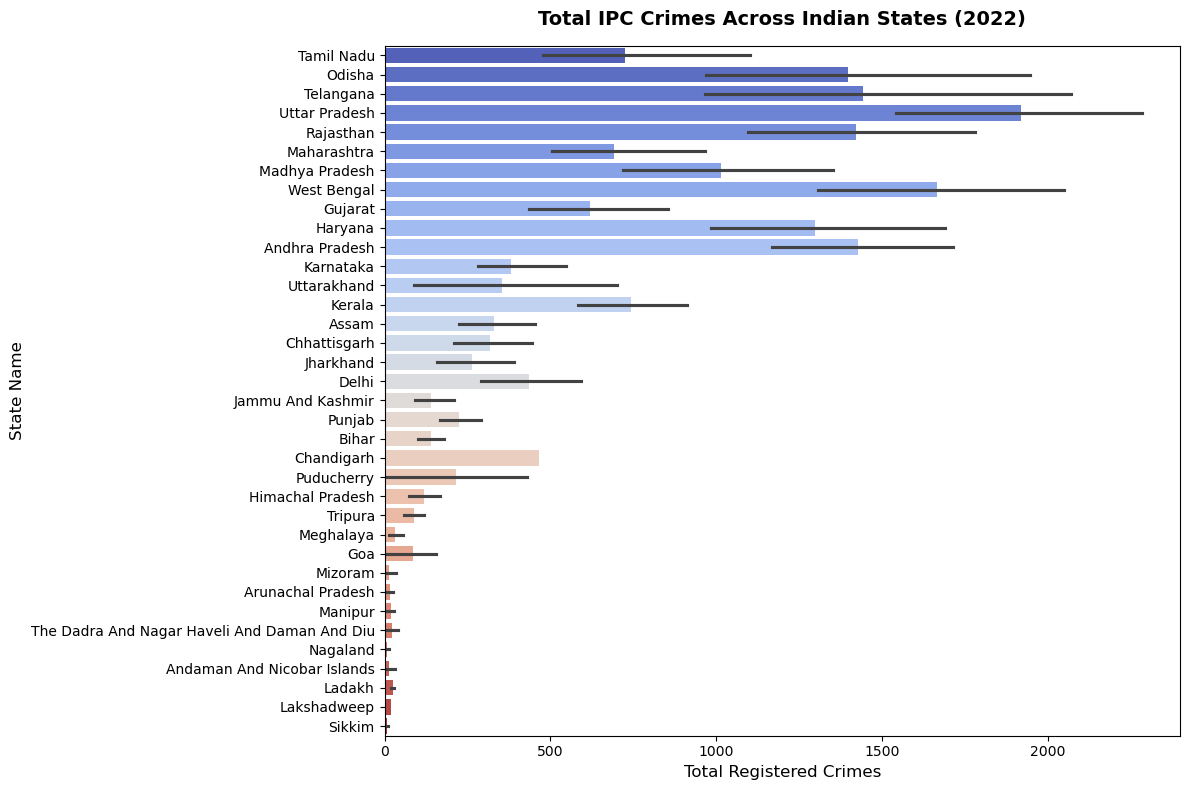

In [16]:
plt.figure(figsize=(12, 8))

sns.barplot(x="Total IPC Crimes", y="State Name", data=df.sort_values(by="Total IPC Crimes", ascending=False), palette="coolwarm")

plt.title("Total IPC Crimes Across Indian States (2022)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Registered Crimes", fontsize=12)
plt.ylabel("State Name", fontsize=12)

plt.tight_layout()
plt.show()

Insights

* The chart represent the total IPC crimes happened across the Indian States during the year 2022
* From the visual analysis we can clearly figure out that the UP has more number of crimes happened
* The least crimes happened were in Sikkim
  


## 2. Total Crimes that happened in Kerala

In [17]:
Kerala_Crimes = df[df["State Name"] == "Kerala"][["Murder", "Acid Attack", "Assault On Women", "Criminal Trespass", 
"Cruelty By Husband Or Relatives", "Criminal Intimidation", "Insult To Modesty Of Women"]].sum().reset_index()

Kerala_Crimes.columns = ["Crime Type", "Total Cases"]

Kerala_Crimes


,Crime Type,Total Cases
0,Murder,319
1,Acid Attack,8
2,Assault On Women,2657
3,Criminal Trespass,1430
4,Cruelty By Husband Or Relatives,4643
5,Criminal Intimidation,871
6,Insult To Modesty Of Women,537


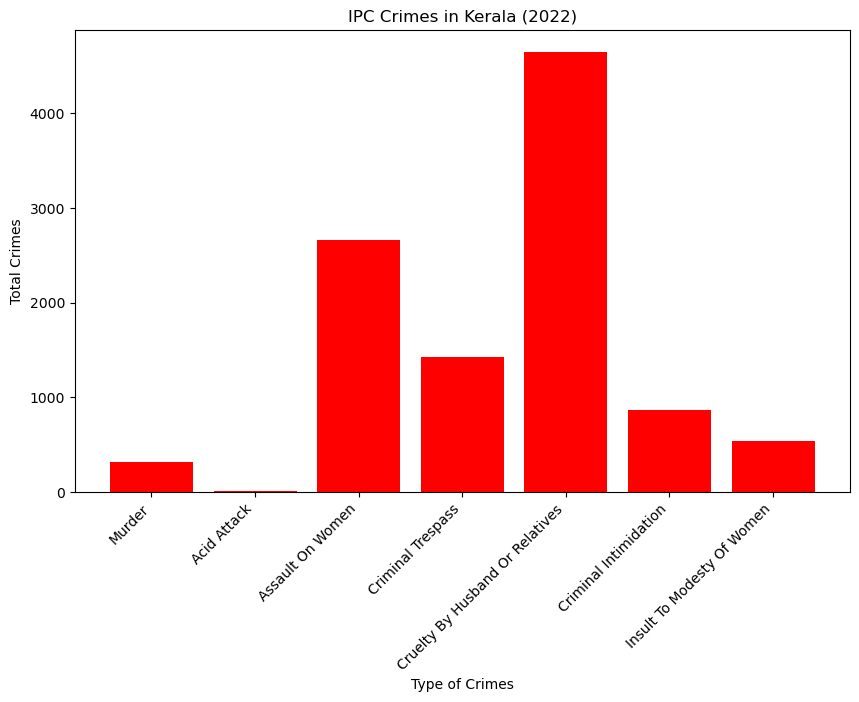

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(Kerala_Crimes["Crime Type"],Kerala_Crimes["Total Cases"],color=["red"])
plt.title("IPC Crimes in Kerala (2022)")
plt.xlabel("Type of Crimes")
plt.ylabel("Total Crimes")
plt.xticks(rotation=45, ha="right")
plt.show()

Insights
* The Visual represnts the crimes that happened in Kerala during 2022
* From this we can understand the high crime that happened is affected to the  married womens from their husband and relatives
* From this we need to understand that the system need to taje more precautions to  prevent all types of crimes that happened in our State and Country


# 3. Specific Crime Types All Over India

In [19]:
crime_types = df[["Murder", "Acid Attack", "Assault On Women", "Criminal Trespass",
"Cruelty By Husband Or Relatives", "Criminal Intimidation", "Insult To Modesty Of Women"]].sum().reset_index()

crime_types.columns = ["Crime Type", "Total Cases"]

crime_types


,Crime Type,Total Cases
0,Murder,28507
1,Acid Attack,202
2,Assault On Women,44780
3,Criminal Trespass,45228
4,Cruelty By Husband Or Relatives,139664
5,Criminal Intimidation,150769
6,Insult To Modesty Of Women,8937


In [20]:
fig = px.pie(crime_types,names="Crime Type",values="Total Cases",title="Types of Crimes All Over India",hole=0.3,
color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_traces(textinfo="percent+label")

fig.show()

Insights
* The pie chart represent the highest crime that happened in India
* From this the top crimes that happened across all over India were the "Cruelity from Husband and Relatives" and "Criminal Indimidation"

# 4. Top 10 States with by total crimes

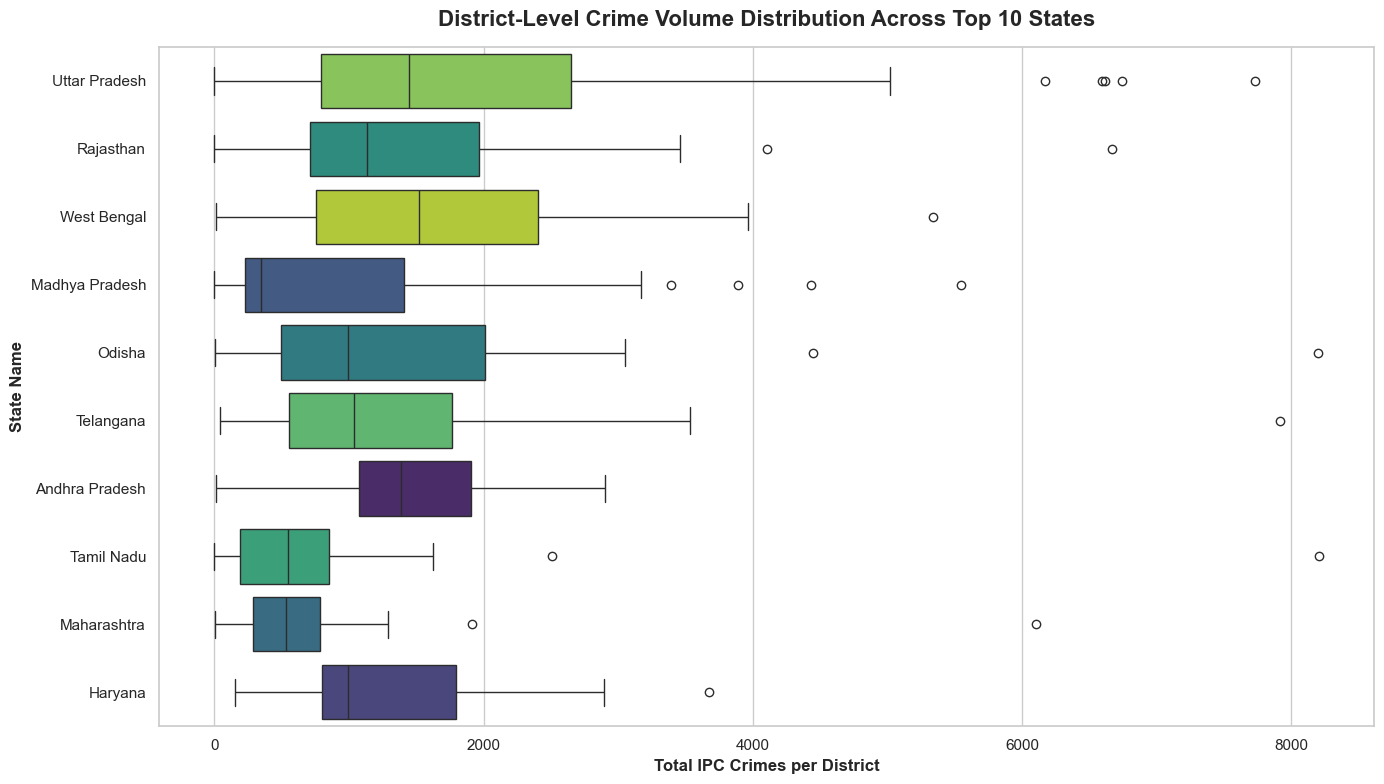

In [21]:
top_10_states = df.groupby("State Name")["Total IPC Crimes"].sum().nlargest(10).index

df_filtered = df[df["State Name"].isin(top_10_states)]

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

box_plot = sns.boxplot(data=df_filtered,y="State Name",x="Total IPC Crimes",hue="State Name",order=top_10_states,palette="viridis")
plt.title("District-Level Crime Volume Distribution Across Top 10 States", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("State Name", fontsize=12, fontweight="bold")
plt.xlabel("Total IPC Crimes per District", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

Insights
* From this visualization we can sort out the top 10 States with highest crime

In [22]:
df.columns

Index(['Id', 'Year', 'State Name', 'State Code', 'District Name',
       'District Code', 'Registration Circles', 'Murder', 'Acid Attack',
       'Assault On Women', 'Criminal Trespass',
       'Cruelty By Husband Or Relatives', 'Criminal Intimidation',
       'Insult To Modesty Of Women', 'Other Ipc Crimes', 'Total IPC Crimes'],
      dtype='object')

# 5. Top States with acid attacks

C:\Users\govin\AppData\Local\Temp\ipykernel_12420\141076986.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




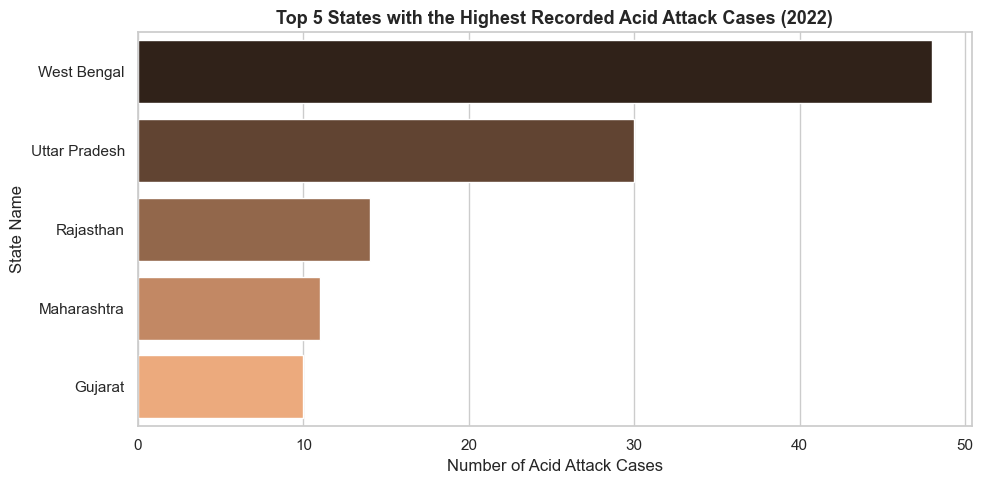

In [23]:
state_acid = df.groupby("State Name")["Acid Attack"].sum().reset_index().sort_values(by="Acid Attack", ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x="Acid Attack", y="State Name", data=state_acid, palette="copper")
plt.title("Top 5 States with the Highest Recorded Acid Attack Cases (2022)", fontsize=13, fontweight="bold")
plt.xlabel("Number of Acid Attack Cases")
plt.ylabel("State Name")
plt.tight_layout()
plt.show()

Insights

* This visual shows the top 5 states that acid attacks happen
* From the visual we can find that the West Bengal has more acid attacks happen
* The govt need to take  more control over the criminals in this state
* It shows how the unsafety of Womens (majority) due to the crimes

# 6.Assault on Women vs. Cruelty by Husband

<function matplotlib.pyplot.show(close=None, block=None)>

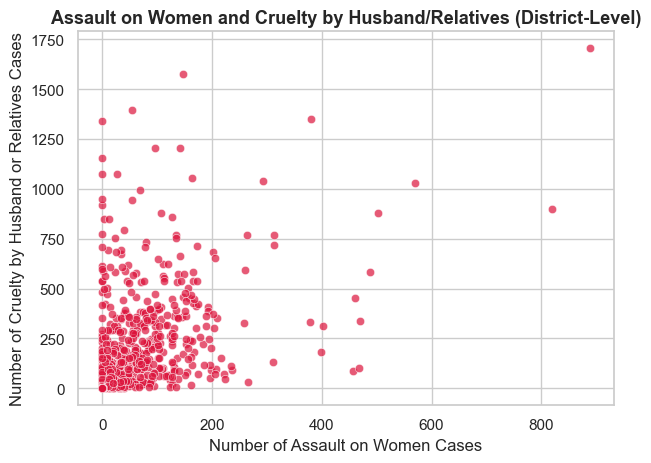

In [24]:
sns.scatterplot(x="Assault On Women", y="Cruelty By Husband Or Relatives", data=df, color="crimson", alpha=0.7)
plt.title("Assault on Women and Cruelty by Husband/Relatives (District-Level)", fontsize=13, fontweight="bold")
plt.xlabel("Number of Assault on Women Cases")
plt.ylabel("Number of Cruelty by Husband or Relatives Cases")
plt.tight_layout()
plt.show

Insights
* This visual is about the cruelity against women that heppens in the district level in India 

# 7. Top 5 Districts for Total Crimes

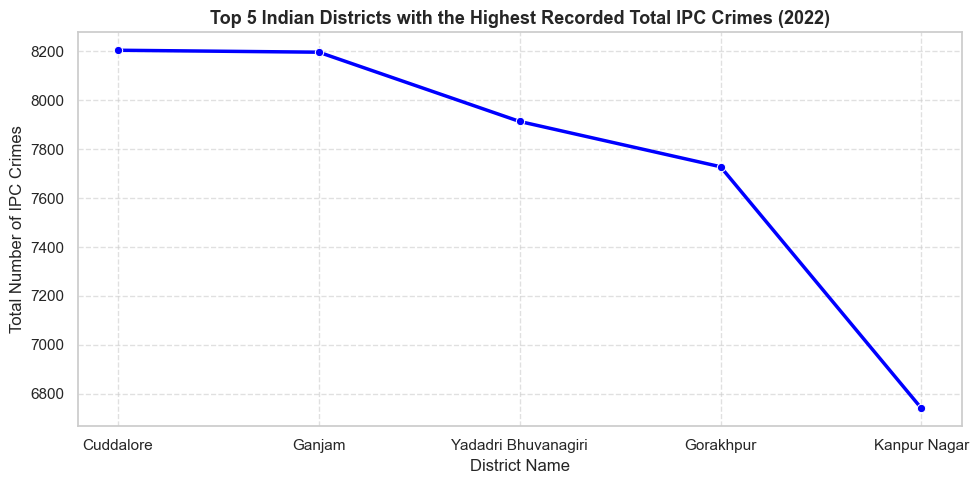

In [25]:
top_districts = df.sort_values(by="Total IPC Crimes", ascending=False).head(5)
plt.figure(figsize=(10, 5))

sns.lineplot(x="District Name", y="Total IPC Crimes", data=top_districts, marker="o", color="blue", linewidth=2.5)
plt.title("Top 5 Indian Districts with the Highest Recorded Total IPC Crimes (2022)", fontsize=13, fontweight="bold")
plt.xlabel("District Name")
plt.ylabel("Total Number of IPC Crimes")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Insights
* This shows the top 5 districts that have the highest crime rates
* We can figure out that "Cuddalore" has the highest crime rates that occured during the year 2022

# 8. Murder and Criminal Intimidation in Top 5 States

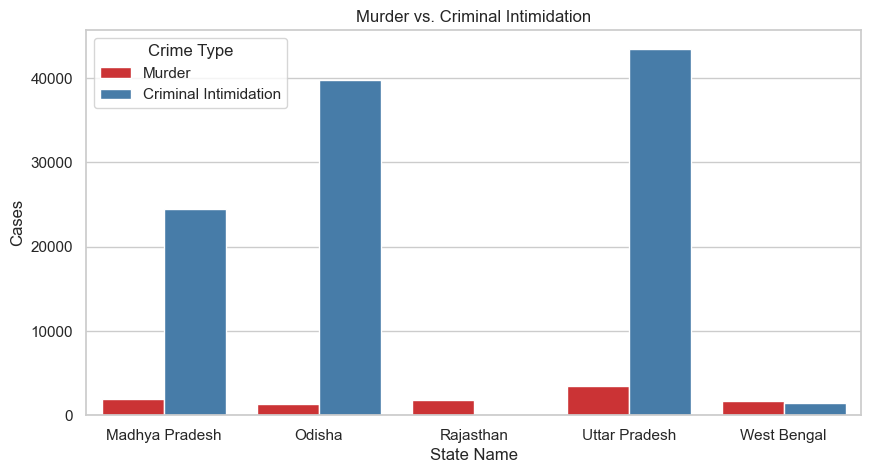

In [26]:
top_5 = df.groupby("State Name")["Total IPC Crimes"].sum().nlargest(5).index

df_5 = df[df["State Name"].isin(top_5)].groupby("State Name")[["Murder", "Criminal Intimidation"]].sum().reset_index()

df_melt = df_5.melt(id_vars="State Name", var_name="Crime Type", value_name="Cases")

plt.figure(figsize=(10, 5))
sns.barplot(x="State Name", y="Cases", hue="Crime Type", data=df_melt, palette="Set1")
plt.title("Murder vs. Criminal Intimidation")
plt.show()

Insights
* In all top states, threats and intimidation cases are much more common than actual murders.

# 9. National Crime Share

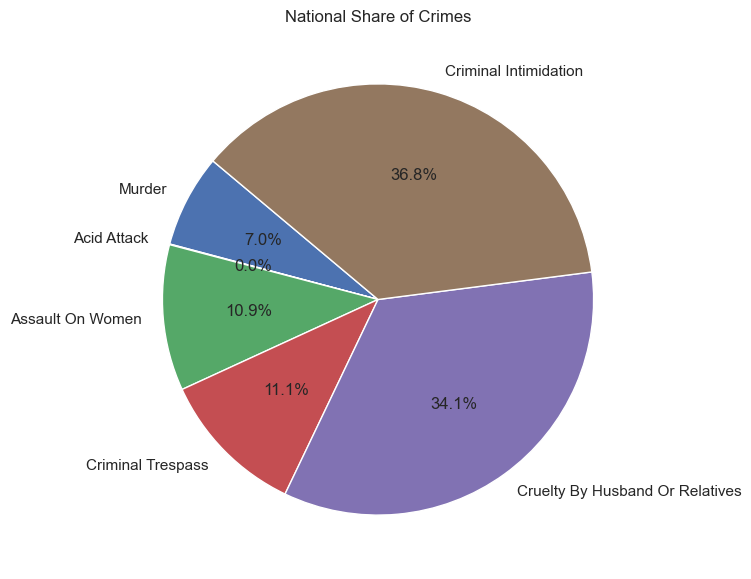

In [27]:
totals = df[["Murder", "Acid Attack", "Assault On Women", "Criminal Trespass", 
"Cruelty By Husband Or Relatives", "Criminal Intimidation"]].sum()

plt.figure(figsize=(7, 7))
plt.pie(totals, labels=totals.index , autopct="%1.1f%%",startangle=140)
plt.title("National Share of Crimes")
plt.show()

Insights

* Crimes against women (like Assault and Domestic Cruelty) make up a very massive slice of the total registered crimes in India.

# 10. Top 10 Districts for Trespass

C:\Users\govin\AppData\Local\Temp\ipykernel_12420\950185090.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




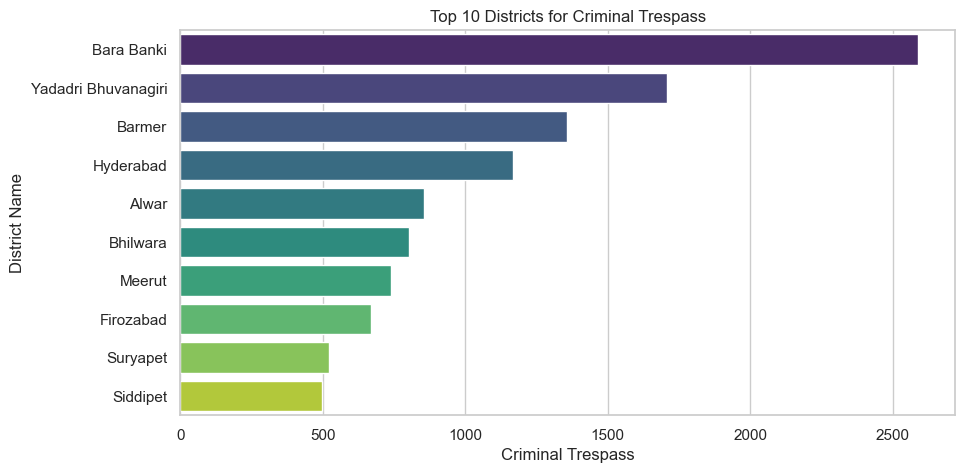

In [28]:
top_trespass = df.sort_values(by="Criminal Trespass", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x="Criminal Trespass", y="District Name", data=top_trespass, palette="viridis")
plt.title("Top 10 Districts for Criminal Trespass")
plt.show()

Insights
* Property break-ins and trespass crimes are heavily concentrated in just a few specific districts rather than being spread out evenly.

## Insights and Overall View of Analysis

The Analysis has been done based on the IPC crimes that happened in India during 2022

This project presents a data-driven exploratory analysis of major crimes recorded under the Indian Penal Code (IPC) across various districts in India for the year 2022. The raw data was sourced from the official Indian Data Portal and features  933 rows and 15 initial attributes, mapping offenses down to specific states and districts

* Data Cleansing & Integrity: Verified that the dataset is highly robust, containing zero missing (null) values and zero duplicate entries, ensuring     the structural integrity of your downstream visualizations.

* Created a core derived metric, "Total IPC Crimes," by horizontally aggregating all specific metric columns (Murder, Acid Attack, Assault On Women,     Criminal Trespass, etc.) for every individual row

* The data was grouped by state to see the bigger picture, instead of looking at individual districts.


  

# Conclusion and Recommendation

* The majority of IPC crimes in India occurred in Uttar Pradesh (UP), while the lowest number was recorded in Sikkim. Looking at Kerala, the state government also needs to take strict action to reduce crime rates. Furthermore, the majority of acid attacks happen in West Bengal, UP, Rajasthan, Maharashtra, and Gujarat, which directly highlights the critical state of women's safety in those regions.

* Grouping the data by state shows a huge imbalance: a few crowded states drive most of the country's crime, while many other areas have very little.

*  Features like Cruelty By Husband Or Relatives, Assault On Women, and Insult To Modesty Of Women hold immense weight in the calculated Total IPC Crimes. The data proves that evaluating a region's safety strictly by its murder rate yields an incomplete picture domestic and gender-targeted crimes represent a massive statistical chunk of law enforcement volume.


"Based on the data, the government should stop judging a region's safety purely by its murder rates. Law enforcement needs to focus heavily on preventing domestic abuse and crimes against women, which dominate the statistics. Instead of treating every state the same, police funds and officers should be sent directly to high-crime areas like Uttar Pradesh and states with high rates of acid attacks".